# Atobb vs TTLJ XGBoost Training and ONNX Export

This notebook trains a first-pass XGBoost classifier using the `Training_Tree` produced by `AtobbMLTree`.

- Signal: `TTToHcToWAToBB-MHc100_MA60.root` by default
- Background: `TTLJ_powheg.root` by default
- Main weight: `weight_train`
- Output model: `xgboost_atobb_ttlJ.onnx`

Before running, check that the ROOT paths below match your actual output directory.


## 1. Imports

Run this in the `MLHEP` kernel/environment where `ROOT`, `xgboost`, `onnxmltools`, and `skl2onnx` are installed.


In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import ROOT
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix

# [ADDED] train/validation overtraining test
from scipy.stats import ks_2samp

import onnx
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster
from skl2onnx.common.data_types import FloatTensorType

# [CHANGED]
# Use the same random seed everywhere instead of writing 42 repeatedly.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2. Input ROOT files

Change these paths if your files are somewhere else.


In [2]:
BASE_DIR = "/data9/Users/eunsu/SKNanoOutput/AtobbMLTree/2024"

SIG_FILES = [
    f"{BASE_DIR}/TTToHcToWAToBB-MHc130_MA90_SingleLepFilter.root",
]

BKG_FILES = [
    f"{BASE_DIR}/TTLJ_powheg.root",
]

TREE_NAME = "Training_Tree"

# ============================================================
# [ADDED] A-mass hypothesis
#
# IMPORTANT:
#   This is the ONLY place where the analysis assumes MA.
#
# AtobbMLTree.cc does NOT know MA anymore.
#
# The exact same TARGET_MA is applied to:
#   - signal
#   - TTLJ
#   - later ttH
#   - later ttZ
#
# Example:
#   MA90 classifier -> TARGET_MA = 90.
#   MA60 classifier -> TARGET_MA = 60.
# ============================================================
TARGET_MHc = 130.0
TARGET_MA = 90.0


MODEL_DIR = "/data9/Users/eunsu/MachineLearning/models"
os.makedirs(MODEL_DIR, exist_ok=True)

# [CHANGED]
# Put the MA hypothesis in the filename so models are not confused later.
MODEL_NAME = f"xgboost_atobb_MHc{int(TARGET_MHc)}_MA{int(TARGET_MA)}_ttlJ"


ONNX_PATH = f"{MODEL_DIR}/{MODEL_NAME}.onnx"
FEATURE_JSON_PATH = f"{MODEL_DIR}/{MODEL_NAME}_features.json"
SCALER_JSON_PATH = f"{MODEL_DIR}/{MODEL_NAME}_scaler.json"
SCALER_PICKLE_PATH = f"{MODEL_DIR}/{MODEL_NAME}_scaler.pkl"

# Background statistics test.
# Change this to 10000, 20000, 50000, 100000, or None.
N_BKG = 100000

# Booster scan. Later, choose one value and rerun for the final model.
NUM_BOOST_ROUND = 500  # Try 20, 50, 100, 200, 300

# Preprocessing choice: "standard", "minmax", or None
# ============================================================
# [CHANGED / RECOMMENDED]
#
# XGBoost decision trees do not require feature standardization.
# None is simpler and avoids reproducing StandardScaler in C++.
#
# Use "standard" only if you explicitly want to keep the old setup.
# ============================================================
SCALER_TYPE = None

print("Signal files:")
for p in SIG_FILES:
    print("  ", p, os.path.exists(p))
print("Background files:")
for p in BKG_FILES:
    print("  ", p, os.path.exists(p))


Signal files:
   /data9/Users/eunsu/SKNanoOutput/AtobbMLTree/2024/TTToHcToWAToBB-MHc130_MA90_SingleLepFilter.root True
Background files:
   /data9/Users/eunsu/SKNanoOutput/AtobbMLTree/2024/TTLJ_powheg.root True


## 3. Load ROOT tree into pandas

This function reads only the branches we need, which is faster and safer than reading everything.


In [3]:
def read_training_tree(files, tree_name="Training_Tree", branches=None):
    dfs = []
    for path in files:
        if not os.path.exists(path):
            raise FileNotFoundError(path)
        f = ROOT.TFile.Open(path, "READ")
        if not f or f.IsZombie():
            raise RuntimeError(f"Cannot open ROOT file: {path}")
        tree = f.Get(tree_name)
        if not tree:
            raise RuntimeError(f"Cannot find tree '{tree_name}' in {path}")
        rdf = ROOT.RDataFrame(tree)
        if branches is None:
            arr = rdf.AsNumpy()
        else:
            arr = rdf.AsNumpy(branches)
        df = pd.DataFrame(arr)
        df["source_file"] = os.path.basename(path)
        dfs.append(df)
        f.Close()
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


## 4. Feature list

First-pass feature set. These are physics-motivated variables from `AtobbMLTree`: jet activity, b-tag topology, bb-pair masses, and ttbar reconstruction variables.

Do **not** include `label`, `weight_*`, or `source_file` as ML inputs.


In [4]:
# ============================================================
# 4. A -> bb reconstruction from raw pair branches
# ============================================================

# First four pT-ordered b-tagged jets:
#
# b0 b1 b2 b3
#
# -> six possible bb combinations
PAIR_NAMES = [
    "01",
    "02",
    "12",
    "03",
    "13",
    "23",
]

PAIR_MASS_COLS = [f"bb_mass_{p}" for p in PAIR_NAMES]
PAIR_DR_COLS = [f"bb_dr_{p}" for p in PAIR_NAMES]
PAIR_PT_COLS = [f"bb_pt_{p}" for p in PAIR_NAMES]
PAIR_ETA_COLS = [f"bb_eta_{p}" for p in PAIR_NAMES]

PAIR_BSCORE_SUM_COLS = [
    f"bb_bscore_sum_{p}" for p in PAIR_NAMES
]

PAIR_BSCORE_MIN_COLS = [
    f"bb_bscore_min_{p}" for p in PAIR_NAMES
]

PAIR_PT_BALANCE_COLS = [
    f"bb_pt_balance_{p}" for p in PAIR_NAMES
]

def add_target_ma_features(df, target_ma):
    """
    Reconstruct an A->bb candidate for a given MA hypothesis.

    The ROOT tree stores only MA-independent raw bb pairs.
    This function:

      1. removes invalid pairs (-999) from consideration,
      2. finds the valid pair with minimum |m_bb - target_ma|,
      3. copies ALL observables of that SAME pair to A_* features.

    IMPORTANT:
      An event with nBJets == 3 is NOT removed.

      For such an event:
        01, 02, 12 -> valid
        03, 13, 23 -> -999 / invalid

      Only the invalid PAIRS are excluded.
    """

    out = df.copy()

    # --------------------------------------------------------
    # Convert six raw pair quantities to 2D arrays:
    #
    # shape = (N_events, 6 pairs)
    # --------------------------------------------------------
    masses = out[PAIR_MASS_COLS].to_numpy(dtype=float)
    drs = out[PAIR_DR_COLS].to_numpy(dtype=float)
    pts = out[PAIR_PT_COLS].to_numpy(dtype=float)
    etas = out[PAIR_ETA_COLS].to_numpy(dtype=float)

    bscore_sums = out[
        PAIR_BSCORE_SUM_COLS
    ].to_numpy(dtype=float)

    bscore_mins = out[
        PAIR_BSCORE_MIN_COLS
    ].to_numpy(dtype=float)

    pt_balances = out[
        PAIR_PT_BALANCE_COLS
    ].to_numpy(dtype=float)


    # ========================================================
    # [IMPORTANT]
    # A pair is valid only when it physically exists.
    #
    # -999 is NOT a physics value.
    # It means "this pair is unavailable".
    #
    # Example nBJets=3:
    #   03/13/23 -> invalid
    # ========================================================
    valid = masses > 0.0


    # --------------------------------------------------------
    # For invalid pairs, assign infinity.
    #
    # They therefore can NEVER be selected as the A candidate.
    # --------------------------------------------------------
    mass_diff = np.where(
        valid,
        np.abs(masses - target_ma),
        np.inf,
    )


    # --------------------------------------------------------
    # Best pair for every event:
    #
    # argmin |m_bb - TARGET_MA|
    # --------------------------------------------------------
    best_idx = np.argmin(mass_diff, axis=1)

    row_idx = np.arange(len(out))


    # ========================================================
    # [ADDED]
    # Reconstruct exactly the A features that used to be
    # generated inside AtobbMLTree.cc.
    #
    # Every variable below comes from THE SAME selected pair.
    # ========================================================

    out["A_mass_best"] = masses[row_idx, best_idx]
    out["A_dr_best"] = drs[row_idx, best_idx]
    out["A_pt_best"] = pts[row_idx, best_idx]
    out["A_eta_best"] = etas[row_idx, best_idx]

    out["A_bscore_sum_best"] = \
        bscore_sums[row_idx, best_idx]

    out["A_bscore_min_best"] = \
        bscore_mins[row_idx, best_idx]

    out["A_pt_balance_best"] = \
        pt_balances[row_idx, best_idx]


    # --------------------------------------------------------
    # Distance from the tested MA hypothesis
    # --------------------------------------------------------
    out["bb_mass_diff_closest_target"] = \
        mass_diff[row_idx, best_idx]


    # --------------------------------------------------------
    # Derived quantities that do not need another ROOT branch
    # --------------------------------------------------------
    out["A_pt_over_mass"] = (
        out["A_pt_best"] / out["A_mass_best"]
    )

    out["A_eta_abs"] = np.abs(out["A_eta_best"])

    out["A_mass_dr"] = (
        out["A_mass_best"] * out["A_dr_best"]
    )


    # --------------------------------------------------------
    # Debug information:
    # which pair was selected?
    #
    # Do NOT use this string as an ML feature.
    # --------------------------------------------------------
    pair_names = np.asarray(PAIR_NAMES)
    out["A_pair_name"] = pair_names[best_idx]


    return out


In [12]:
WEIGHT_COL = "weight_train"
LABEL_COL = "label"


# ============================================================
# [CHANGED]
# Features stored DIRECTLY in AtobbMLTree ROOT.
# ============================================================
ROOT_EVENT_FEATURES = [

    # Event activity
    "HT",
    "ST",
    "MET_Pt",

    # Multiplicity
    "nJets",
    "nJets_for_count",
    "nBJets",

    # Lepton
    "Lepton0_Pt",
    "Lepton0_Eta",

    # MA-independent bb summaries
    "bb_mass_min_all",
    "bb_mass_max_all",
    "bb_mass_at_min_dr",
    "bb_mass_spread_all",
    "bb_dr_min_all",
    # "bb_dr_max_all",

    # b-tag topology
    "bscore_max",
    "bscore_2nd",
    "bscore_3rd",
    "bscore_sum",
    "bscore_sum_top4",

    # ttbar-hypothesis reconstruction
    "best_chi2",
    "had_W_mass",
    "had_top_mass",
    "lep_W_mass",
    "lep_top_mass",
]

# ============================================================
# [ADDED]
# Raw pair branches.
#
# These are reconstruction inputs, NOT final ML features.
# ============================================================

RAW_PAIR_BRANCHES = (
    PAIR_MASS_COLS
    + PAIR_DR_COLS
    + PAIR_PT_COLS
    + PAIR_ETA_COLS
    + PAIR_BSCORE_SUM_COLS
    + PAIR_BSCORE_MIN_COLS
    + PAIR_PT_BALANCE_COLS
)

# ============================================================
# [ADDED]
# Features created AFTER selecting the TARGET_MA-dependent pair.
# ============================================================

DERIVED_A_FEATURES = [
    "A_mass_best",
    "A_dr_best",
    "A_pt_best",
    "A_bscore_sum_best",
    "A_bscore_min_best",

    "bb_mass_diff_closest_target",

    "A_pt_over_mass",
    "A_eta_abs",
    "A_mass_dr",
    "A_pt_balance_best",
]

# ============================================================
# Final scalar inputs to XGBoost
#
# IMPORTANT:
# RAW_PAIR_BRANCHES are NOT passed directly to the BDT.
# ============================================================

FEATURES = (
    ROOT_EVENT_FEATURES
    + DERIVED_A_FEATURES
)

# ============================================================
# ROOT reading list
#
# A_mass_best etc. are NOT ROOT branches anymore.
# Therefore they must NOT appear here.
# ============================================================

BRANCHES_TO_READ = sorted(set(
    ROOT_EVENT_FEATURES
    + RAW_PAIR_BRANCHES
    + [
        WEIGHT_COL,
        "weight_nominal",
        LABEL_COL,
    ]
))


print(f"Number of final ML features = {len(FEATURES)}")
print(FEATURES)

print()
print(f"Number of ROOT branches to read = {len(BRANCHES_TO_READ)}")
print(BRANCHES_TO_READ)

Number of final ML features = 33
['HT', 'ST', 'MET_Pt', 'nJets', 'nJets_for_count', 'nBJets', 'Lepton0_Pt', 'Lepton0_Eta', 'bb_mass_min_all', 'bb_mass_max_all', 'bb_mass_at_min_dr', 'bb_mass_spread_all', 'bb_dr_min_all', 'bscore_max', 'bscore_2nd', 'bscore_3rd', 'bscore_sum', 'bscore_sum_top4', 'best_chi2', 'had_W_mass', 'had_top_mass', 'lep_W_mass', 'lep_top_mass', 'A_mass_best', 'A_dr_best', 'A_pt_best', 'A_bscore_sum_best', 'A_bscore_min_best', 'bb_mass_diff_closest_target', 'A_pt_over_mass', 'A_eta_abs', 'A_mass_dr', 'A_pt_balance_best']

Number of ROOT branches to read = 68
['HT', 'Lepton0_Eta', 'Lepton0_Pt', 'MET_Pt', 'ST', 'bb_bscore_min_01', 'bb_bscore_min_02', 'bb_bscore_min_03', 'bb_bscore_min_12', 'bb_bscore_min_13', 'bb_bscore_min_23', 'bb_bscore_sum_01', 'bb_bscore_sum_02', 'bb_bscore_sum_03', 'bb_bscore_sum_12', 'bb_bscore_sum_13', 'bb_bscore_sum_23', 'bb_dr_01', 'bb_dr_02', 'bb_dr_03', 'bb_dr_12', 'bb_dr_13', 'bb_dr_23', 'bb_dr_min_all', 'bb_eta_01', 'bb_eta_02', 'bb_eta

## 5. Read signal and background samples

For this notebook, we override the label explicitly to avoid relying on sample-name parsing.


In [13]:
# ============================================================
# 6. Read signal and background
# ============================================================

df_sig = read_training_tree(
    SIG_FILES,
    TREE_NAME,
    branches=BRANCHES_TO_READ,
)

df_bkg = read_training_tree(
    BKG_FILES,
    TREE_NAME,
    branches=BRANCHES_TO_READ,
)


# Explicit labels
df_sig[LABEL_COL] = 1
df_bkg[LABEL_COL] = 0


# ============================================================
# [ADDED]
# Reconstruct the A candidate using the SAME TARGET_MA
# hypothesis for signal and background.
# ============================================================

df_sig = add_target_ma_features(
    df_sig,
    TARGET_MA,
)

df_bkg = add_target_ma_features(
    df_bkg,
    TARGET_MA,
)


print("Before background limit:")
print("  signal entries:", len(df_sig))
print("  bkg entries   :", len(df_bkg))


if N_BKG is not None and len(df_bkg) > N_BKG:

    df_bkg = (
        df_bkg
        .sample(
            n=N_BKG,
            random_state=RANDOM_SEED,
        )
        .reset_index(drop=True)
    )


print("After background limit:")
print("  signal entries:", len(df_sig))
print("  bkg entries   :", len(df_bkg))

Before background limit:
  signal entries: 15772
  bkg entries   : 2245142
After background limit:
  signal entries: 15772
  bkg entries   : 100000


In [14]:
# ============================================================
# [ADDED] A reconstruction sanity check
# ============================================================

CHECK_COLS = [
    "nBJets",
    "A_pair_name",
    "A_mass_best",
    "A_dr_best",
    "A_pt_best",
    "A_bscore_sum_best",
    "bb_mass_diff_closest_target",
]

print("[Signal]")
display(df_sig[CHECK_COLS].head(10))

print("[Background]")
display(df_bkg[CHECK_COLS].head(10))

print("Signal chosen-pair fraction:")
print(
    df_sig["A_pair_name"]
    .value_counts(normalize=True)
    .sort_index()
)

print("\nBackground chosen-pair fraction:")
print(
    df_bkg["A_pair_name"]
    .value_counts(normalize=True)
    .sort_index()
)

# ============================================================
# [ADDED]
# Verify that nBJets == 3 events are NOT lost just because
# 03/13/23 are -999.
# ============================================================

sig_3b = df_sig[df_sig["nBJets"] == 3]

print("Signal nBJets==3:", len(sig_3b))

print(
    sig_3b[
        [
            "bb_mass_01",
            "bb_mass_02",
            "bb_mass_12",
            "bb_mass_03",
            "bb_mass_13",
            "bb_mass_23",
            "A_pair_name",
            "A_mass_best",
        ]
    ].head()
)

[Signal]


,nBJets,A_pair_name,A_mass_best,A_dr_best,A_pt_best,A_bscore_sum_best,bb_mass_diff_closest_target
0,4,12,69.195251,0.462186,295.158020,1.107758,20.804749
1,3,12,145.287125,2.547451,57.591724,1.989136,55.287125
2,4,23,83.809853,1.010010,163.344925,0.442871,6.190147
3,3,01,72.468857,1.002876,130.314011,1.996338,17.531143
4,5,23,85.927689,3.339480,21.280828,1.199829,4.072311
5,4,12,82.439987,1.306136,116.755920,1.997437,7.560013
6,4,12,99.953911,2.808184,19.359367,1.788818,9.953911
7,4,12,84.930901,1.087891,147.312958,1.958130,5.069099
8,3,12,51.517769,0.439715,225.851669,1.994995,38.482231
9,3,01,135.479919,1.126447,223.792633,1.994873,45.479919


[Background]


,nBJets,A_pair_name,A_mass_best,A_dr_best,A_pt_best,A_bscore_sum_best,bb_mass_diff_closest_target
0,3,12,87.640892,0.811861,201.692764,0.719666,2.359108
1,3,02,91.239487,1.691881,98.325508,1.995972,1.239487
2,3,12,380.099274,2.780432,86.305756,1.957031,290.099274
3,3,02,73.766045,2.171623,108.492706,1.162445,16.233955
4,3,01,79.750427,2.217590,45.169155,1.666748,10.249573
5,3,12,44.747684,0.603300,124.725006,1.132416,45.252316
6,5,03,94.608727,1.402395,217.170074,1.185303,4.608727
7,3,01,92.926422,1.463583,105.484863,0.550323,2.926422
8,3,02,70.889275,0.807206,174.544998,1.137146,19.110725
9,3,02,80.094193,0.452944,457.768372,1.364075,9.905807


Signal chosen-pair fraction:
A_pair_name
01    0.175057
02    0.261666
03    0.077225
12    0.324563
13    0.086673
23    0.074816
Name: proportion, dtype: float64

Background chosen-pair fraction:
A_pair_name
01    0.17379
02    0.30898
03    0.02190
12    0.43519
13    0.02940
23    0.03074
Name: proportion, dtype: float64
Signal nBJets==3: 9041
    bb_mass_01  bb_mass_02  bb_mass_12  bb_mass_03  bb_mass_13  bb_mass_23  \
1   404.887177  267.542999  145.287125      -999.0      -999.0      -999.0   
3    72.468857   61.660000   65.128334      -999.0      -999.0      -999.0   
8   406.091949  233.860931   51.517769      -999.0      -999.0      -999.0   
9   135.479919  210.657700  173.617096      -999.0      -999.0      -999.0   
11  105.558372  128.389313   56.890915      -999.0      -999.0      -999.0   

   A_pair_name  A_mass_best  
1           12   145.287125  
3           01    72.468857  
8           12    51.517769  
9           01   135.479919  
11          01   105.558372  


## 6. Basic cleaning and weight handling

- Replace `inf` with `NaN`
- Drop rows with invalid feature/weight values
- Use `abs(weight_train)` by default for training stability
- Normalize total signal/background weights to similar scale

If you want signed MC weights later, keep them for final histograms, but for first classifier training this is safer.


In [15]:
def print_bad_values(df, features, name):
    print(f"[{name}] bad value check")
    for feat in features:
        n_nan = df[feat].isna().sum()
        n_inf = np.isinf(df[feat]).sum()
        n_sentinel = (df[feat] <= -998).sum()
        if n_nan or n_inf or n_sentinel:
            print(f"  {feat:15s} NaN={n_nan:6d}, Inf={n_inf:6d}, <=-998={n_sentinel:6d}")

print_bad_values(df_sig, FEATURES, "signal raw")
print_bad_values(df_bkg, FEATURES, "bkg raw")


[signal raw] bad value check
  best_chi2       NaN=     0, Inf=     0, <=-998=    58
  had_W_mass      NaN=     0, Inf=     0, <=-998=    58
  had_top_mass    NaN=     0, Inf=     0, <=-998=    58
  lep_W_mass      NaN=     0, Inf=     0, <=-998=    58
  lep_top_mass    NaN=     0, Inf=     0, <=-998=    58
[bkg raw] bad value check
  best_chi2       NaN=     0, Inf=     0, <=-998=    26
  had_W_mass      NaN=     0, Inf=     0, <=-998=    26
  had_top_mass    NaN=     0, Inf=     0, <=-998=    26
  lep_W_mass      NaN=     0, Inf=     0, <=-998=    26
  lep_top_mass    NaN=     0, Inf=     0, <=-998=    26


In [16]:
# ============================================================
# DEBUG: find which feature is killing all events
# ============================================================

def check_features_before_cleaning(df, features, name):

    print(f"\n========== {name} ==========")
    print("Total entries:", len(df))

    for feat in features:

        if feat not in df.columns:
            print(f"[MISSING COLUMN] {feat}")
            continue

        values = df[feat]

        n_total = len(values)
        n_nan = values.isna().sum()
        n_inf = np.isinf(values).sum()
        n_sentinel = (values <= -998).sum()
        n_valid = (
            np.isfinite(values)
            & (values > -998)
        ).sum()

        print(
            f"{feat:35s} "
            f"valid={n_valid:7d}  "
            f"sentinel={n_sentinel:7d}  "
            f"nan={n_nan:7d}  "
            f"inf={n_inf:7d}"
        )


check_features_before_cleaning(
    df_sig,
    FEATURES,
    "SIGNAL"
)

check_features_before_cleaning(
    df_bkg,
    FEATURES,
    "BACKGROUND"
)


========== SIGNAL ==========
Total entries: 15772
HT                                  valid=  15772  sentinel=      0  nan=      0  inf=      0
ST                                  valid=  15772  sentinel=      0  nan=      0  inf=      0
MET_Pt                              valid=  15772  sentinel=      0  nan=      0  inf=      0
nJets                               valid=  15772  sentinel=      0  nan=      0  inf=      0
nJets_for_count                     valid=  15772  sentinel=      0  nan=      0  inf=      0
nBJets                              valid=  15772  sentinel=      0  nan=      0  inf=      0
Lepton0_Pt                          valid=  15772  sentinel=      0  nan=      0  inf=      0
Lepton0_Eta                         valid=  15772  sentinel=      0  nan=      0  inf=      0
bb_mass_min_all                     valid=  15772  sentinel=      0  nan=      0  inf=      0
bb_mass_max_all                     valid=  15772  sentinel=      0  nan=      0  inf=      0
bb_mass_a

In [17]:
print("\n".join(FEATURES))

HT
ST
MET_Pt
nJets
nJets_for_count
nBJets
Lepton0_Pt
Lepton0_Eta
bb_mass_min_all
bb_mass_max_all
bb_mass_at_min_dr
bb_mass_spread_all
bb_dr_min_all
bscore_max
bscore_2nd
bscore_3rd
bscore_sum
bscore_sum_top4
best_chi2
had_W_mass
had_top_mass
lep_W_mass
lep_top_mass
A_mass_best
A_dr_best
A_pt_best
A_bscore_sum_best
A_bscore_min_best
bb_mass_diff_closest_target
A_pt_over_mass
A_eta_abs
A_mass_dr
A_pt_balance_best


In [18]:
# ============================================================
# Cleaning and training-weight preparation
#
# IMPORTANT:
#   FEATURES contains only FINAL ML input features.
#
#   Raw bb-pair branches such as
#       bb_mass_03, bb_dr_03, ...
#   may contain -999 when the pair does not exist.
#
#   Those raw pair branches must NOT be included directly in
#   FEATURES. They are used only before this step to construct
#   the valid TARGET_MA-dependent A candidate.
# ============================================================

def clean_df(df, features, weight_col):

    # Final ML input features + label + original MC weight
    use_cols = features + [LABEL_COL, weight_col]

    out = df[use_cols].copy()

    # --------------------------------------------------------
    # [1] Remove NaN / +/-inf
    # --------------------------------------------------------
    out = out.replace([np.inf, -np.inf], np.nan)


    # --------------------------------------------------------
    # [2] Handle sentinel values such as -999
    #
    # At this stage we check only FINAL ML features.
    #
    # Raw pair -999 values have already been handled when
    # constructing A_mass_best, A_dr_best, etc.
    #
    # Therefore:
    #   nBJets == 3 event is NOT removed merely because
    #   bb_mass_03/13/23 were -999.
    # --------------------------------------------------------
    for feat in features:
        out.loc[out[feat] <= -998, feat] = np.nan


    # Drop events only if a FINAL ML feature is undefined
    out = out.dropna(subset=use_cols).copy()


    # --------------------------------------------------------
    # [3] Prepare training weight
    #
    # Keep the original weight_train unchanged for reference.
    #
    # For classifier training, use |weight_train|.
    # --------------------------------------------------------
    out[weight_col] = out[weight_col].astype(float)

    out["ml_weight"] = np.abs(out[weight_col])


    # --------------------------------------------------------
    # [4] Remove invalid / zero training weights
    #
    # NOTE:
    # We do NOT remove negative original MC weights before abs().
    # --------------------------------------------------------
    out = out[
        np.isfinite(out["ml_weight"])
        & (out["ml_weight"] > 0)
    ].copy()

    return out


# Apply exactly the same cleaning to signal and background
df_sig_clean = clean_df(
    df_sig,
    FEATURES,
    WEIGHT_COL,
)

df_bkg_clean = clean_df(
    df_bkg,
    FEATURES,
    WEIGHT_COL,
)

sig_sumw = df_sig_clean["ml_weight"].sum()
bkg_sumw = df_bkg_clean["ml_weight"].sum()

if sig_sumw <= 0 or bkg_sumw <= 0:
    raise RuntimeError(
        f"Invalid total training weight: "
        f"signal={sig_sumw}, background={bkg_sumw}"
    )

# class total weight를 같게 맞추되, total scale은 이벤트 수 정도로 유지
n_sig = len(df_sig_clean)
n_bkg = len(df_bkg_clean)
target_sumw_each = 0.5 * (n_sig + n_bkg)

df_sig_clean["ml_weight"] *= target_sumw_each / sig_sumw
df_bkg_clean["ml_weight"] *= target_sumw_each / bkg_sumw

print("After cleaning:")
print("  signal entries:", n_sig, "sum ml weight:", df_sig_clean["ml_weight"].sum())
print("  bkg entries   :", n_bkg, "sum ml weight:", df_bkg_clean["ml_weight"].sum())


print("Raw weight summary:")
print("signal weight_train")
print(df_sig_clean[WEIGHT_COL].describe())
print("background weight_train")
print(df_bkg_clean[WEIGHT_COL].describe())

print("ML weight summary:")
print("signal ml_weight")
print(df_sig_clean["ml_weight"].describe())
print("background ml_weight")
print(df_bkg_clean["ml_weight"].describe())

After cleaning:
  signal entries: 15714 sum ml weight: 57844.00000000001
  bkg entries   : 99974 sum ml weight: 57844.0
Raw weight summary:
signal weight_train
count    15714.000000
mean         0.008686
std          0.005365
min          0.001945
25%          0.005852
50%          0.007219
75%          0.010602
max          0.109298
Name: weight_train, dtype: float64
background weight_train
count    99974.000000
mean         0.089336
std          0.056887
min         -1.560752
25%          0.060898
50%          0.073213
75%          0.109508
max          2.061168
Name: weight_train, dtype: float64
ML weight summary:
signal ml_weight
count    15714.000000
mean         3.681049
std          2.273393
min          0.824371
25%          2.479882
50%          3.059295
75%          4.492942
max         46.317644
Name: ml_weight, dtype: float64
background ml_weight
count    99974.000000
mean         0.578590
std          0.356991
min          0.127040
25%          0.391643
50%          0.4706

## 7. Quick sanity plots

These are not for final presentation, just to confirm signal/background shape differences.


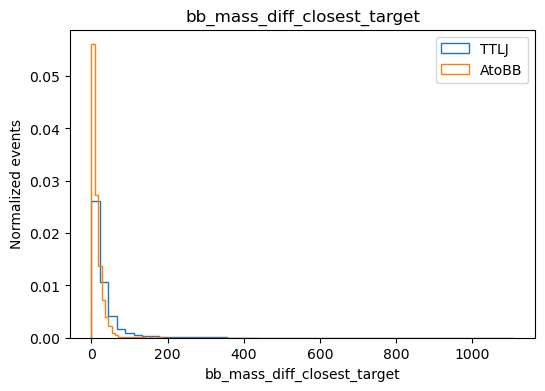

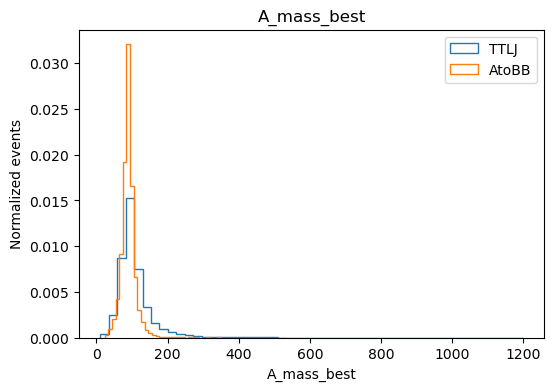

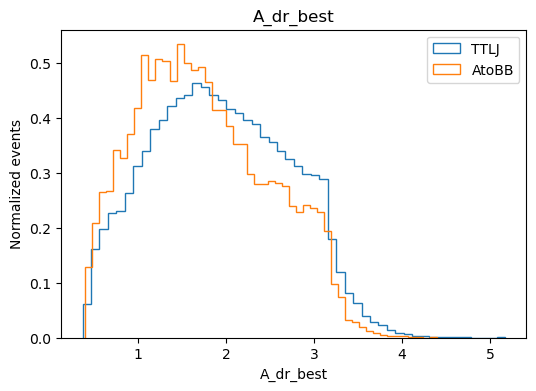

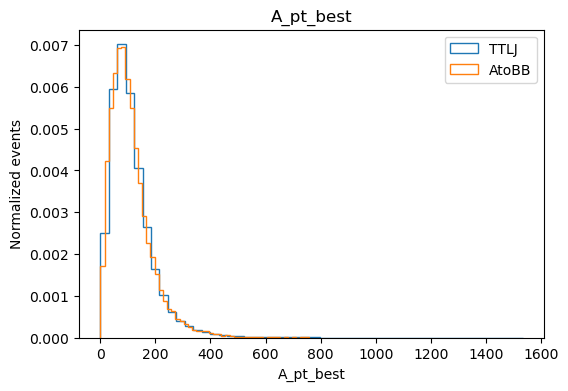

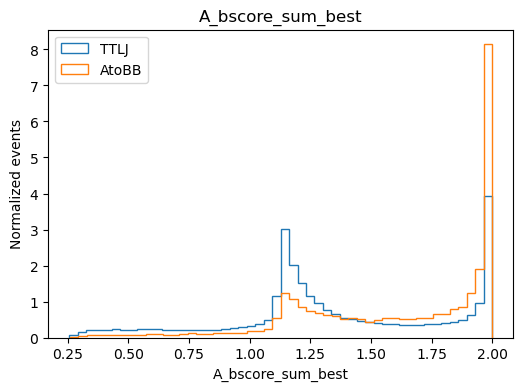

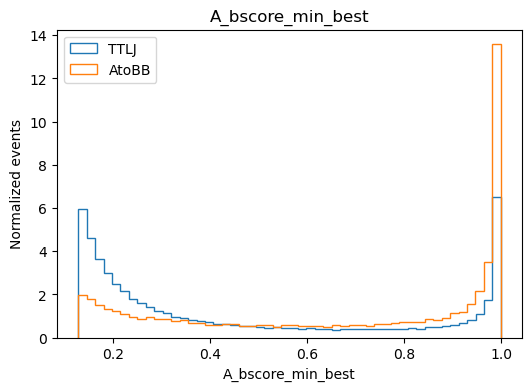

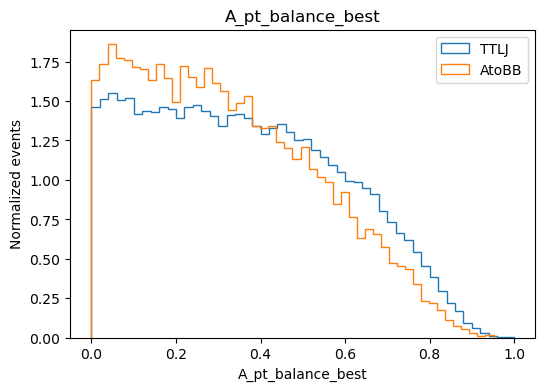

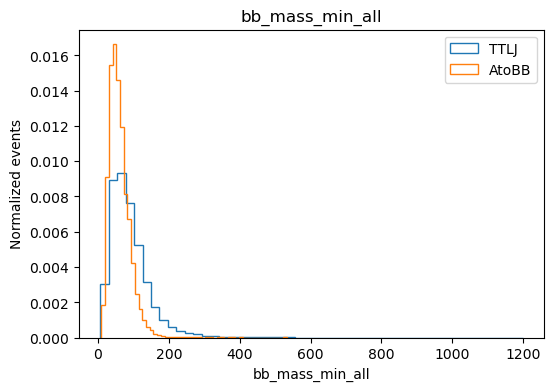

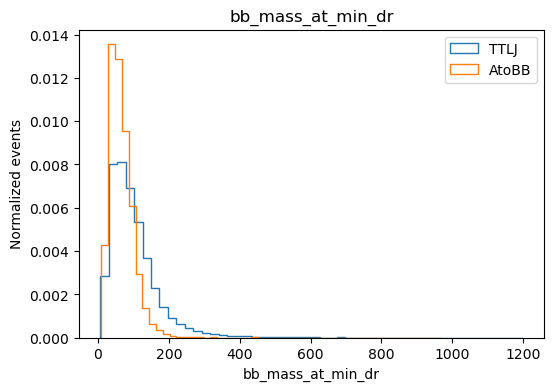

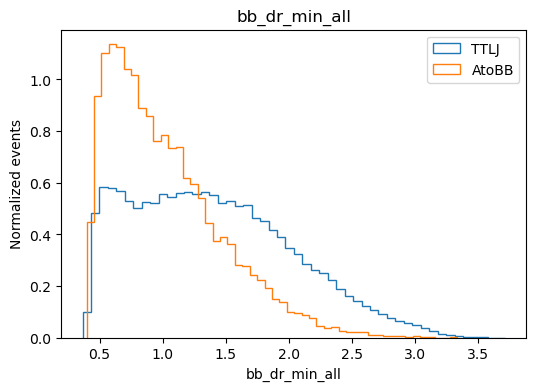

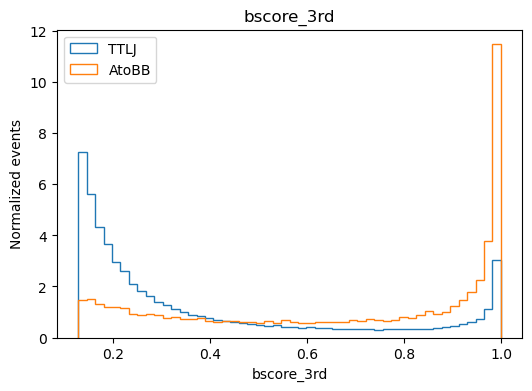

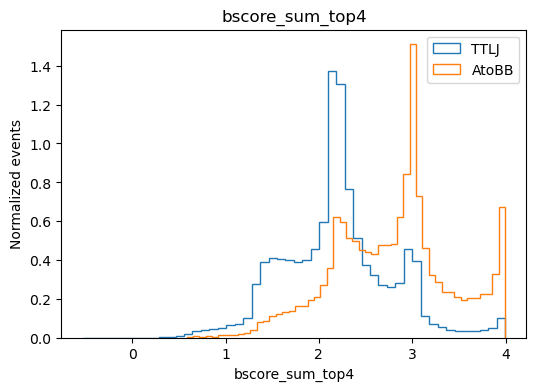

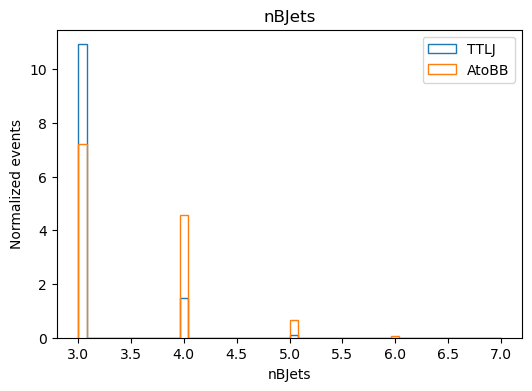

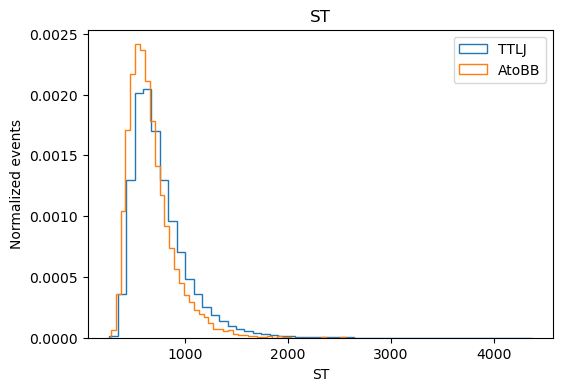

In [19]:
def plot_feature(sig, bkg, feature, bins=50, x_range=None, logy=False):
    plt.figure(figsize=(6, 4))
    plt.hist(bkg[feature], bins=bins, range=x_range, histtype="step", density=True, label="TTLJ")
    plt.hist(sig[feature], bins=bins, range=x_range, histtype="step", density=True, label="AtoBB")
    if logy:
        plt.yscale("log")
    plt.xlabel(feature)
    plt.ylabel("Normalized events")
    plt.title(feature)
    plt.legend()
    plt.show()

# for feat in ["nJets", "HT", "ST", "bb_mass_min_all", "bb_mass_max_all", "A_mass_best", "bb_dr_min_all", "bb_dr_max_all", "MET_Pt", "A_dr_best", "A_pt_best", "bscore_sum_top4", "best_chi2"]:
#     plot_feature(df_sig_clean, df_bkg_clean, feat, bins=50)

PLOT_FEATURES = [
    "bb_mass_diff_closest_target",
    "A_mass_best",
    "A_dr_best",
    "A_pt_best",
    "A_bscore_sum_best",
    "A_bscore_min_best",
    "A_pt_balance_best",

    "bb_mass_min_all",
    "bb_mass_at_min_dr",
    "bb_dr_min_all",

    "bscore_3rd",
    "bscore_sum_top4",

    "nBJets",
    "ST",
]
for feat in PLOT_FEATURES:
    plot_feature(df_sig_clean,df_bkg_clean,feat,bins=50,x_range=None,logy=False)


In [20]:
from sklearn.metrics import roc_auc_score

all_auc = []

for feat in FEATURES:

    sig = df_sig_clean[feat].to_numpy()
    bkg = df_bkg_clean[feat].to_numpy()

    y_true = np.concatenate([
        np.ones(len(sig)),
        np.zeros(len(bkg))
    ])

    score = np.concatenate([sig, bkg])

    auc = roc_auc_score(y_true, score)

    if auc < 0.5:
        auc = 1.0 - auc

    all_auc.append((feat, auc))

all_auc = sorted(all_auc, key=lambda x: x[1], reverse=True)

for feat, auc in all_auc:
    print(f"{feat:30s} {auc:.4f}")

bscore_sum_top4                0.7602
bscore_3rd                     0.7551
bb_dr_min_all                  0.6791
A_bscore_min_best              0.6770
A_bscore_sum_best              0.6732
bb_mass_min_all                0.6682
bb_mass_diff_closest_target    0.6644
bb_mass_at_min_dr              0.6603
bscore_2nd                     0.6517
nBJets                         0.6507
bscore_sum                     0.6165
A_mass_dr                      0.6128
A_mass_best                    0.6090
bb_mass_max_all                0.6070
ST                             0.6019
HT                             0.5933
bscore_max                     0.5777
Lepton0_Pt                     0.5709
A_dr_best                      0.5690
A_pt_balance_best              0.5489
bb_mass_spread_all             0.5458
MET_Pt                         0.5442
nJets                          0.5429
A_pt_over_mass                 0.5416
had_W_mass                     0.5398
lep_top_mass                   0.5387
had_top_mass

## 8. Train / validation split

Use stratified split so both train and validation contain signal and background.


In [21]:
df_all = pd.concat([df_sig_clean, df_bkg_clean], ignore_index=True)

train_df, val_df = train_test_split(
    df_all,
    test_size=0.2,
    random_state=42,
    stratify=df_all[LABEL_COL],
)

X_train = train_df[FEATURES].copy()
y_train = train_df[LABEL_COL].astype(int).copy()
w_train = train_df["ml_weight"].astype(float).copy()
# w_train = np.ones(len(train_df))

X_val = val_df[FEATURES].copy()
y_val = val_df[LABEL_COL].astype(int).copy()
w_val = val_df["ml_weight"].astype(float).copy()
# w_val = np.ones(len(val_df))

used_columns = list(X_train.columns)

if SCALER_TYPE == "standard":
    scaler = StandardScaler()
elif SCALER_TYPE == "minmax":
    scaler = MinMaxScaler()
elif SCALER_TYPE is None:
    scaler = None
else:
    raise ValueError(f"Unknown SCALER_TYPE = {SCALER_TYPE}")

if scaler is not None:
    X_train_np = scaler.fit_transform(X_train)
    X_val_np = scaler.transform(X_val)
else:
    X_train_np = X_train.to_numpy(dtype=np.float32)
    X_val_np = X_val.to_numpy(dtype=np.float32)

X_train = pd.DataFrame(X_train_np, columns=used_columns)
X_val = pd.DataFrame(X_val_np, columns=used_columns)

# ONNX/XGBoost conversion is safer with integer feature names.
X_train.columns = range(len(used_columns))
X_val.columns = range(len(used_columns))

print("Train label counts:")
print(y_train.value_counts())
print("Validation label counts:")
print(y_val.value_counts())
print("used columns:")
for i, c in enumerate(used_columns):
    print(f"  {i:02d}: {c}")




Train label counts:
label
0    79979
1    12571
Name: count, dtype: int64
Validation label counts:
label
0    19995
1     3143
Name: count, dtype: int64
used columns:
  00: HT
  01: ST
  02: MET_Pt
  03: nJets
  04: nJets_for_count
  05: nBJets
  06: Lepton0_Pt
  07: Lepton0_Eta
  08: bb_mass_min_all
  09: bb_mass_max_all
  10: bb_mass_at_min_dr
  11: bb_mass_spread_all
  12: bb_dr_min_all
  13: bscore_max
  14: bscore_2nd
  15: bscore_3rd
  16: bscore_sum
  17: bscore_sum_top4
  18: best_chi2
  19: had_W_mass
  20: had_top_mass
  21: lep_W_mass
  22: lep_top_mass
  23: A_mass_best
  24: A_dr_best
  25: A_pt_best
  26: A_bscore_sum_best
  27: A_bscore_min_best
  28: bb_mass_diff_closest_target
  29: A_pt_over_mass
  30: A_eta_abs
  31: A_mass_dr
  32: A_pt_balance_best


## 9. Train XGBoost model

This is a first-pass model. Tune `max_depth`, `eta`, and `num_boost_round` later.


In [22]:
dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train)
dval = xgb.DMatrix(X_val, label=y_val, weight=w_val)

params = {
    "max_depth": 4,
    "eta": 0.05,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    # "min_child_weight": 10,
    # "lambda": 1.0,
    # "alpha": 0.5,
    "random_state": 42,
    "tree_method": "hist",
    # "scale_pos_weight": len(df_bkg_clean) / len(df_sig_clean)
}

evals_result = {}
model = xgb.train(
    params,
    dtrain,
    num_boost_round=NUM_BOOST_ROUND,
    evals=[(dtrain, "train"), (dval, "validation")],
    early_stopping_rounds=50,
    evals_result=evals_result,
    verbose_eval=50,
)

print("Finished training with num_boost_round =", NUM_BOOST_ROUND)
print("Final train logloss     =", evals_result["train"]["logloss"][-1])
print("Final validation logloss=", evals_result["validation"]["logloss"][-1])

[0]	train-logloss:0.67925	validation-logloss:0.67975
[50]	train-logloss:0.49564	validation-logloss:0.50520
[100]	train-logloss:0.47006	validation-logloss:0.48631
[150]	train-logloss:0.45713	validation-logloss:0.47956
[200]	train-logloss:0.44675	validation-logloss:0.47564
[250]	train-logloss:0.43860	validation-logloss:0.47364
[300]	train-logloss:0.43158	validation-logloss:0.47292
[350]	train-logloss:0.42443	validation-logloss:0.47223
[400]	train-logloss:0.41839	validation-logloss:0.47163
[450]	train-logloss:0.41213	validation-logloss:0.47125
[499]	train-logloss:0.40672	validation-logloss:0.47138
Finished training with num_boost_round = 500
Final train logloss     = 0.4067151955485663
Final validation logloss= 0.47137774820460365


In [23]:
RUN_SCAN = False

if RUN_SCAN:
    scan_bkg_entries = [10000, 20000, 50000, 100000]
    scan_rounds = [20, 50, 100, 200, 300]
    scan_results = []

    for n_bkg in scan_bkg_entries:
        temp_bkg = df_bkg_clean.sample(n=min(n_bkg, len(df_bkg_clean)), random_state=42).copy()
        temp_all = pd.concat([df_sig_clean, temp_bkg], ignore_index=True)
        tr, va = train_test_split(temp_all, test_size=0.2, random_state=42, stratify=temp_all[LABEL_COL])

        Xtr_raw = tr[FEATURES].astype(float)
        Xva_raw = va[FEATURES].astype(float)
        ytr = tr[LABEL_COL].astype(int)
        yva = va[LABEL_COL].astype(int)
        wtr = tr["ml_weight"].astype(float)
        wva = va["ml_weight"].astype(float)

        scan_scaler = StandardScaler()
        Xtr = pd.DataFrame(scan_scaler.fit_transform(Xtr_raw), columns=range(len(FEATURES)))
        Xva = pd.DataFrame(scan_scaler.transform(Xva_raw), columns=range(len(FEATURES)))

        dtr = xgb.DMatrix(Xtr, label=ytr, weight=wtr)
        dva = xgb.DMatrix(Xva, label=yva, weight=wva)

        for n_round in scan_rounds:
            m = xgb.train(params, dtr, num_boost_round=n_round, evals=[(dva, "val")], verbose_eval=False)
            pred = m.predict(dva)
            fpr, tpr, _ = roc_curve(yva, pred, sample_weight=wva)
            auc_val = auc(fpr, tpr)
            scan_results.append({"n_bkg": n_bkg, "num_boost_round": n_round, "auc": auc_val})

    scan_df = pd.DataFrame(scan_results)
    display(scan_df)

## 10. Evaluation: ROC and score distributions


Train AUC      = 0.899562
Validation AUC = 0.857591
AUC gap        = 0.041972


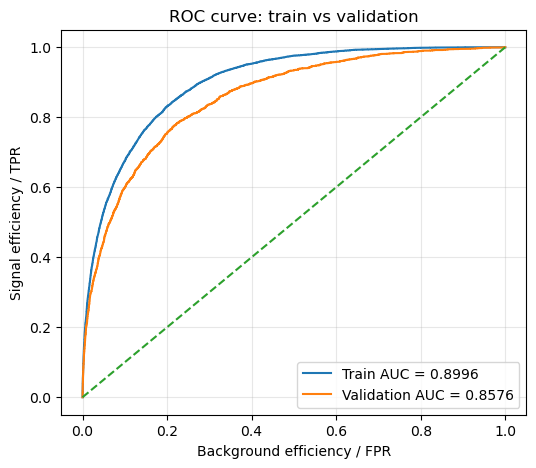

In [30]:
from sklearn.metrics import roc_curve, auc as sklearn_auc


# ============================================================
# Predictions
# ============================================================

pred_train = model.predict(dtrain)
pred_val = model.predict(dval)


# ============================================================
# Train ROC / AUC
# ============================================================

fpr_train, tpr_train, _ = roc_curve(
    y_train,
    pred_train,
    sample_weight=w_train,
)

auc_train = sklearn_auc(
    fpr_train,
    tpr_train,
)


# ============================================================
# Validation ROC / AUC
# ============================================================

fpr_val, tpr_val, _ = roc_curve(
    y_val,
    pred_val,
    sample_weight=w_val,
)

auc_val = sklearn_auc(
    fpr_val,
    tpr_val,
)


# ============================================================
# Print AUC comparison
# ============================================================

print(f"Train AUC      = {auc_train:.6f}")
print(f"Validation AUC = {auc_val:.6f}")
print(f"AUC gap        = {auc_train - auc_val:.6f}")


# ============================================================
# ROC curve: train vs validation
# ============================================================

plt.figure(figsize=(6, 5))

plt.plot(
    fpr_train,
    tpr_train,
    label=f"Train AUC = {auc_train:.4f}",
)

plt.plot(
    fpr_val,
    tpr_val,
    label=f"Validation AUC = {auc_val:.4f}",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

plt.xlabel("Background efficiency / FPR")
plt.ylabel("Signal efficiency / TPR")
plt.title("ROC curve: train vs validation")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

AUC = 0.8575907173376222


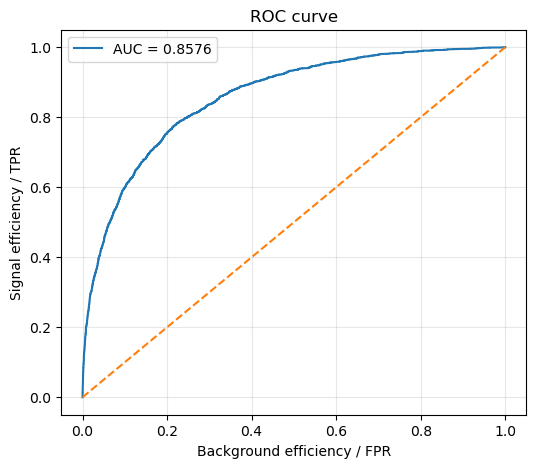

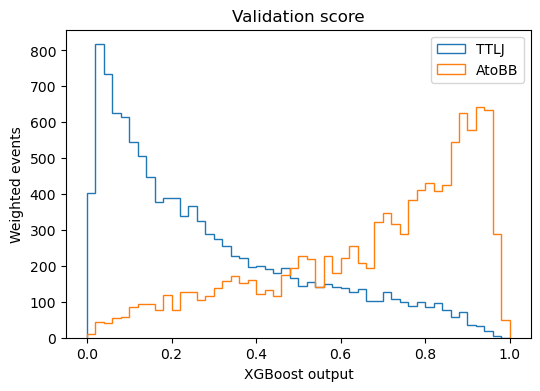

In [31]:
from sklearn.metrics import roc_curve, auc as sklearn_auc

y_pred = model.predict(dval)

fpr, tpr, thresholds = roc_curve(y_val, y_pred, sample_weight=w_val)
auc_val = sklearn_auc(fpr, tpr)
print("AUC =", auc_val)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_val:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Background efficiency / FPR")
plt.ylabel("Signal efficiency / TPR")
plt.title("ROC curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(y_pred[y_val.to_numpy() == 0], bins=50, range=(0,1), histtype="step", weights=w_val[y_val == 0], label="TTLJ")
plt.hist(y_pred[y_val.to_numpy() == 1], bins=50, range=(0,1), histtype="step", weights=w_val[y_val == 1], label="AtoBB")
plt.xlabel("XGBoost output")
plt.ylabel("Weighted events")
plt.legend()
plt.title("Validation score")
plt.show()


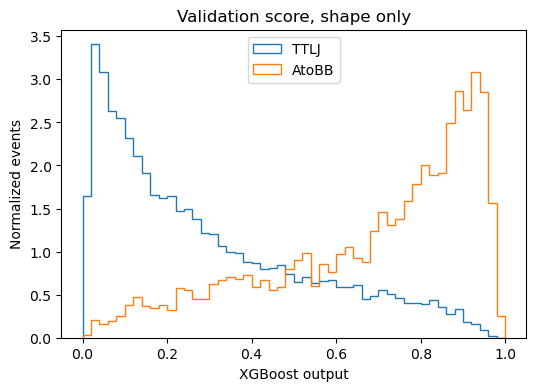

In [25]:
plt.figure(figsize=(6,4))
plt.hist(y_pred[y_val.to_numpy() == 0], bins=50, range=(0,1),
         histtype="step", density=True, label="TTLJ")
plt.hist(y_pred[y_val.to_numpy() == 1], bins=50, range=(0,1),
         histtype="step", density=True, label="AtoBB")
plt.xlabel("XGBoost output")
plt.ylabel("Normalized events")
plt.legend()
plt.title("Validation score, shape only")
plt.show()

## 11. Overtraining check

Compare train vs validation score shapes.


[KS overtraining check]
Signal:     D = 0.0662, p = 4.914e-10
Background: D = 0.0112, p = 0.03471


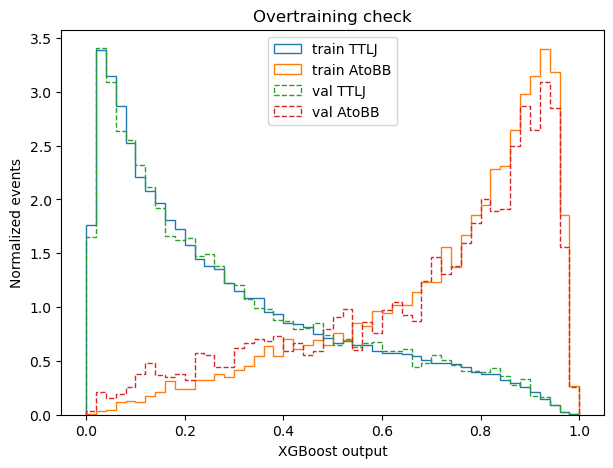

In [26]:
pred_train = model.predict(dtrain)
pred_val = model.predict(dval)

y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
w_train_np = w_train.to_numpy()
w_val_np = w_val.to_numpy()

# ============================================================
# [ADDED] Kolmogorov-Smirnov overtraining test
#
# Compare:
#   signal train vs signal validation
#   bkg    train vs bkg    validation
#
# Do NOT compare signal vs background here.
# That would measure discrimination, not overtraining.
#
# scipy.stats.ks_2samp is UNWEIGHTED.
# ============================================================

ks_sig = ks_2samp(
    pred_train[y_train_np == 1],
    pred_val[y_val_np == 1],
)

ks_bkg = ks_2samp(
    pred_train[y_train_np == 0],
    pred_val[y_val_np == 0],
)


print("[KS overtraining check]")

print(
    f"Signal:     "
    f"D = {ks_sig.statistic:.4f}, "
    f"p = {ks_sig.pvalue:.4g}"
)

print(
    f"Background: "
    f"D = {ks_bkg.statistic:.4f}, "
    f"p = {ks_bkg.pvalue:.4g}"
)

plt.figure(figsize=(7, 5))
plt.hist(pred_train[y_train_np == 0], bins=50, range=(0, 1), histtype="step", density=True, label="train TTLJ")
plt.hist(pred_train[y_train_np == 1], bins=50, range=(0, 1), histtype="step", density=True, label="train AtoBB")
plt.hist(pred_val[y_val_np == 0], bins=50, range=(0, 1), histtype="step", density=True, linestyle="--", label="val TTLJ")
plt.hist(pred_val[y_val_np == 1], bins=50, range=(0, 1), histtype="step", density=True, linestyle="--", label="val AtoBB")
plt.xlabel("XGBoost output")
plt.ylabel("Normalized events")
plt.title("Overtraining check")
plt.legend()
plt.show()


## 12. Feature importance


                        feature        gain
0               bscore_sum_top4  364.066376
1             bb_mass_at_min_dr  157.487259
2                    bscore_3rd  151.405380
3               bb_mass_min_all   99.466476
4   bb_mass_diff_closest_target   76.408951
5               bb_mass_max_all   74.179077
6                 bb_dr_min_all   73.201530
7                        nBJets   67.779564
8                            ST   62.366741
9                     A_mass_dr   52.762703
10                   Lepton0_Pt   46.026600
11                  A_mass_best   43.128399
12              nJets_for_count   39.265240
13            A_bscore_min_best   38.489033
14                   had_W_mass   32.113113
15                 had_top_mass   31.258692
16           bb_mass_spread_all   29.167074
17                    A_dr_best   28.906534
18                           HT   28.626865
19                 lep_top_mass   28.549898
20                       MET_Pt   27.581429
21                   bscore_max 

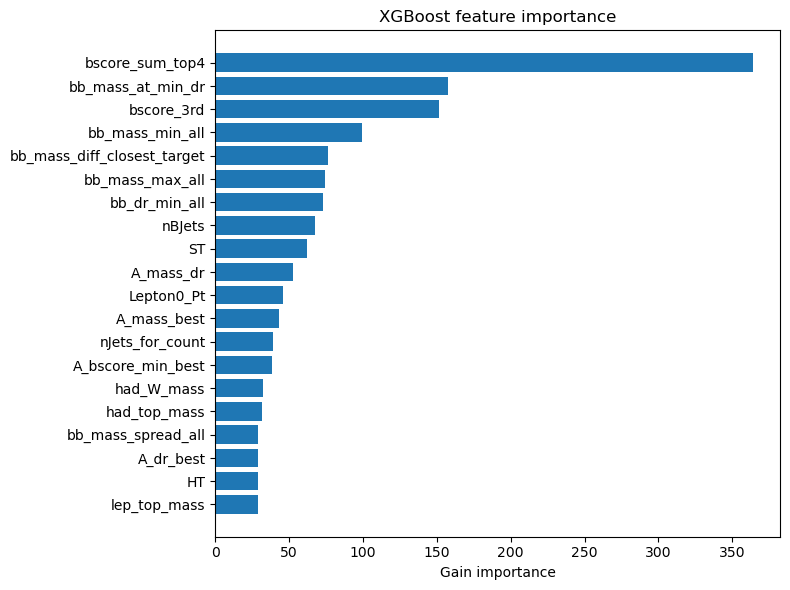

In [27]:
importance = model.get_score(importance_type="gain")
importance_named = []
for key, val in importance.items():
    # key is like f0, f1, ...
    idx = int(key[1:]) if key.startswith("f") else int(key)
    importance_named.append((used_columns[idx], val))
importance_named = sorted(importance_named, key=lambda x: x[1], reverse=True)

imp_df = pd.DataFrame(importance_named, columns=["feature", "gain"])
print(imp_df.head(30))

plt.figure(figsize=(8,6))
plot_df = imp_df.head(20).iloc[::-1]
plt.barh(plot_df["feature"], plot_df["gain"])
plt.xlabel("Gain importance")
plt.title("XGBoost feature importance")
plt.tight_layout()
plt.show()


In [29]:
PLOT_DIR = f"{MODEL_DIR}/scan_plots_0811"
os.makedirs(PLOT_DIR, exist_ok=True)
from sklearn.metrics import roc_curve, auc as sklearn_auc


def save_current_plots(tag):
    # 1. ROC
    y_pred = model.predict(dval)
    fpr, tpr, thresholds = roc_curve(y_val, y_pred, sample_weight=w_val)
    auc_val = sklearn_auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_val:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Background efficiency / FPR")
    plt.ylabel("Signal efficiency / TPR")
    plt.title(f"ROC curve: {tag}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/roc_{tag}.png", dpi=150)
    plt.close()

    # 2. validation score
    plt.figure(figsize=(6, 4))
    plt.hist(y_pred[y_val.to_numpy() == 0], bins=50, range=(0, 1),
             histtype="step", density=True, weights=w_val.to_numpy()[y_val.to_numpy() == 0],
             label="TTLJ")
    plt.hist(y_pred[y_val.to_numpy() == 1], bins=50, range=(0, 1),
             histtype="step", density=True, weights=w_val.to_numpy()[y_val.to_numpy() == 1],
             label="AtoBB")
    plt.xlabel("XGBoost output")
    plt.ylabel("Normalized events")
    plt.title(f"Validation score: {tag}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/score_{tag}.png", dpi=150)
    plt.close()

    # 2.1. shape only
    plt.figure(figsize=(6,4))
    plt.hist(y_pred[y_val.to_numpy() == 0], bins=50, range=(0,1),
             histtype="step", density=True, label="TTLJ")
    plt.hist(y_pred[y_val.to_numpy() == 1], bins=50, range=(0,1),
             histtype="step", density=True, label="AtoBB")
    plt.xlabel("XGBoost output")
    plt.ylabel("Normalized events")
    plt.legend()
    plt.title("Validation score, shape only")
    plt.savefig(f"{PLOT_DIR}/score_shape_{tag}.png", dpi=150)
    plt.close() 

    # 3. overtraining check
    pred_train = model.predict(dtrain)
    pred_val = model.predict(dval)

    y_train_np = y_train.to_numpy()
    y_val_np = y_val.to_numpy()
    w_train_np = w_train.to_numpy()
    w_val_np = w_val.to_numpy()

    plt.figure(figsize=(7, 5))
    plt.hist(pred_train[y_train_np == 0], bins=50, range=(0, 1), histtype="step",
             density=True, weights=w_train_np[y_train_np == 0], label="train TTLJ")
    plt.hist(pred_train[y_train_np == 1], bins=50, range=(0, 1), histtype="step",
             density=True, weights=w_train_np[y_train_np == 1], label="train AtoBB")
    plt.hist(pred_val[y_val_np == 0], bins=50, range=(0, 1), histtype="step",
             density=True, linestyle="--", weights=w_val_np[y_val_np == 0], label="val TTLJ")
    plt.hist(pred_val[y_val_np == 1], bins=50, range=(0, 1), histtype="step",
             density=True, linestyle="--", weights=w_val_np[y_val_np == 1], label="val AtoBB")
    plt.xlabel("XGBoost output")
    plt.ylabel("Normalized events")
    plt.title(f"Overtraining check: {tag}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/overtraining_{tag}.png", dpi=150)
    plt.close()

    # 4. feature importance
    importance = model.get_score(importance_type="gain")
    importance_named = []
    for key, val in importance.items():
        # key is like f0, f1, ...
        idx = int(key[1:]) if key.startswith("f") else int(key)
        importance_named.append((used_columns[idx], val))
    importance_named = sorted(importance_named, key=lambda x: x[1], reverse=True)

    imp_df = pd.DataFrame(importance_named, columns=["feature", "gain"])
    print(imp_df.head(30))

    plt.figure(figsize=(8,6))
    plot_df = imp_df.head(20).iloc[::-1]
    plt.barh(plot_df["feature"], plot_df["gain"])
    plt.xlabel("Gain importance")
    plt.title("XGBoost feature importance")
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/importance_{tag}.png", dpi=150)
    plt.close()



tag = f"nbkg{N_BKG}_boost{NUM_BOOST_ROUND}"
auc_val = save_current_plots(tag)
print("Saved plots with tag:", tag, "AUC:", auc_val)

# [FIXED]
# return auc_val

                        feature        gain
0               bscore_sum_top4  364.066376
1             bb_mass_at_min_dr  157.487259
2                    bscore_3rd  151.405380
3               bb_mass_min_all   99.466476
4   bb_mass_diff_closest_target   76.408951
5               bb_mass_max_all   74.179077
6                 bb_dr_min_all   73.201530
7                        nBJets   67.779564
8                            ST   62.366741
9                     A_mass_dr   52.762703
10                   Lepton0_Pt   46.026600
11                  A_mass_best   43.128399
12              nJets_for_count   39.265240
13            A_bscore_min_best   38.489033
14                   had_W_mass   32.113113
15                 had_top_mass   31.258692
16           bb_mass_spread_all   29.167074
17                    A_dr_best   28.906534
18                           HT   28.626865
19                 lep_top_mass   28.549898
20                       MET_Pt   27.581429
21                   bscore_max 

## 13. Export to ONNX

This creates `xgboost_atobb_ttlJ.onnx` and a JSON file containing the exact feature order.

The C++ inference input vector **must use this exact order**.


In [33]:
from onnxmltools.convert.common.data_types import FloatTensorType

initial_type = [("input", FloatTensorType([None, len(used_columns)]))]
onnx_model = convert_xgboost_booster(model, initial_types=initial_type, target_opset=12)
onnx.save_model(onnx_model, ONNX_PATH)

metadata = {
    "features": used_columns,
    "feature_indices": {name: i for i, name in enumerate(used_columns)},
    # ========================================================
    # [ADDED]
    # This classifier is explicitly conditioned on this
    # reconstructed MA hypothesis.
    # ========================================================
    "target_ma": TARGET_MA,
    
    "scaler_type": SCALER_TYPE,
    "n_bkg": N_BKG,
    "num_boost_round": NUM_BOOST_ROUND,
    "params": params,
    "auc": float(auc_val),
}

with open(FEATURE_JSON_PATH, "w") as f:
    json.dump(metadata, f, indent=4)

if scaler is not None:
    with open(SCALER_PICKLE_PATH, "wb") as f:
        pickle.dump(scaler, f)

    scaler_json = {
        "scaler_type": SCALER_TYPE,
        "features": used_columns,
    }
    if SCALER_TYPE == "standard":
        scaler_json["mean"] = scaler.mean_.tolist()
        scaler_json["scale"] = scaler.scale_.tolist()
    elif SCALER_TYPE == "minmax":
        scaler_json["min"] = scaler.min_.tolist()
        scaler_json["scale"] = scaler.scale_.tolist()
        scaler_json["data_min"] = scaler.data_min_.tolist()
        scaler_json["data_max"] = scaler.data_max_.tolist()

    with open(SCALER_JSON_PATH, "w") as f:
        json.dump(scaler_json, f, indent=4)

print("Saved ONNX:", ONNX_PATH)
print("Saved feature metadata:", FEATURE_JSON_PATH)
print("Saved scaler json:", SCALER_JSON_PATH)
print("Saved scaler pickle:", SCALER_PICKLE_PATH)

Saved ONNX: /data9/Users/eunsu/MachineLearning/models/xgboost_atobb_MHc130_MA90_ttlJ.onnx
Saved feature metadata: /data9/Users/eunsu/MachineLearning/models/xgboost_atobb_MHc130_MA90_ttlJ_features.json
Saved scaler json: /data9/Users/eunsu/MachineLearning/models/xgboost_atobb_MHc130_MA90_ttlJ_scaler.json
Saved scaler pickle: /data9/Users/eunsu/MachineLearning/models/xgboost_atobb_MHc130_MA90_ttlJ_scaler.pkl


## 14. Validate ONNX output against XGBoost output

This checks that the exported ONNX model gives the same score as the original XGBoost model.


ONNX inputs: [<onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7fc7e89206b0>]
ONNX outputs: [<onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7fc7e887e370>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7fc7e8921c30>]
0 <class 'numpy.ndarray'> (23138,)
1 <class 'numpy.ndarray'> (23138, 2)
ONNX pred ready: (23138,)
max |xgb - onnx| = 5.066395e-07


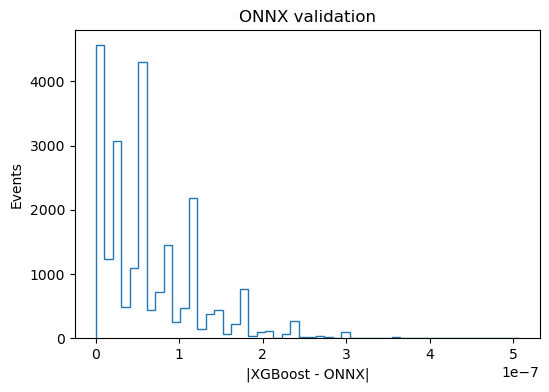

In [34]:
import onnxruntime as ort

sess = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
print("ONNX inputs:", sess.get_inputs())
print("ONNX outputs:", sess.get_outputs())

X_val_np = X_val.to_numpy(dtype=np.float32)
onnx_outputs = sess.run(None, {"input": X_val_np})

# For binary:logistic conversion, output name/shape can differ by package version.
# Print shapes first.
for i, out in enumerate(onnx_outputs):
    print(i, type(out), getattr(out, "shape", None))

# Try common cases.
y_pred_onnx = None
if len(onnx_outputs) == 1:
    y_pred_onnx = np.asarray(onnx_outputs[0]).reshape(-1)
else:
    # Often: labels, probabilities. probabilities may be array or list of dicts.
    prob = onnx_outputs[-1]
    if isinstance(prob, list):
        y_pred_onnx = np.array([p[1] if 1 in p else p.get("1") for p in prob], dtype=float)
    else:
        prob = np.asarray(prob)
        if prob.ndim == 2 and prob.shape[1] >= 2:
            y_pred_onnx = prob[:, 1]
        else:
            y_pred_onnx = prob.reshape(-1)

print("ONNX pred ready:", y_pred_onnx.shape)
print("max |xgb - onnx| =", np.max(np.abs(y_pred - y_pred_onnx)))

plt.figure(figsize=(6,4))
plt.hist(np.abs(y_pred - y_pred_onnx), bins=50, histtype="step")
plt.xlabel("|XGBoost - ONNX|")
plt.ylabel("Events")
plt.title("ONNX validation")
plt.show()


## 15. C++ inference note

For SKNano C++ inference, use the exact feature order saved in `xgboost_atobb_ttlJ_features.json`.

The input shape should be:

```cpp
input_shape_xgboost["input"] = {1, N_FEATURES};
```

where `N_FEATURES` is printed above.
